In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configuración estética para que los gráficos queden "Wow"
plt.style.use('ggplot')
sns.set_palette("viridis")

In [3]:

# 1. Cargar los archivos reales
eur = pd.read_csv('europa_final.csv')
esp = pd.read_csv('espana_final.csv')

# 2. Selección de variables que SÍ existen en tus CSVs
# Usamos 'absentismo' como objetivo en Europa
features = ['desempleo', 'horas_hab_trabajadas', 'poblacion_neet', 'empleo']
target = 'absentismo'

# 3. Limpieza técnica para el modelo
# Filtramos solo las columnas que usaremos para no tener errores
df_eu_model = eur[features + [target, 'pais', 'año', 'region']].dropna()

# 4. Escalado (Preparando para K-Means y Red Neuronal)
scaler = StandardScaler()
eur_scaled = scaler.fit_transform(df_eu_model[features])

print(f"¡Listo! Dataset de Europa verificado con {df_eu_model.shape[0]} registros.")
print(f"Variables seleccionadas: {features}")

¡Listo! Dataset de Europa verificado con 476 registros.
Variables seleccionadas: ['desempleo', 'horas_hab_trabajadas', 'poblacion_neet', 'empleo']


primer modelo. k-means

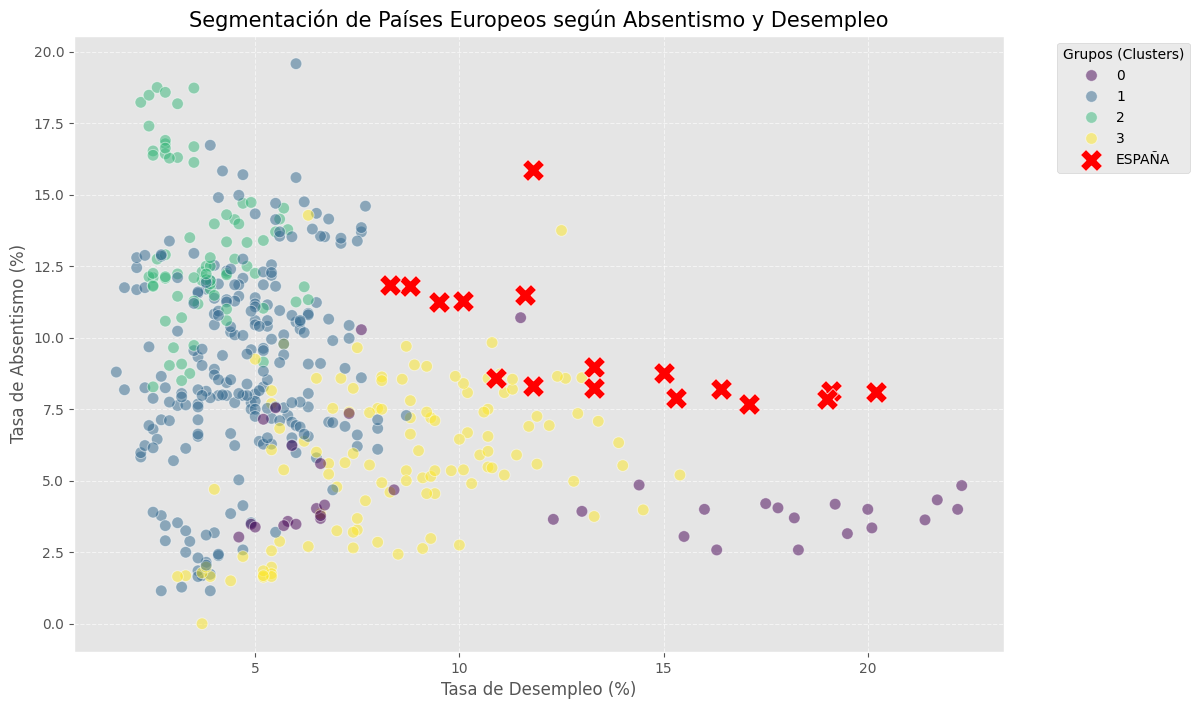

Valores medios por cada grupo:
         desempleo  horas_hab_trabajadas  poblacion_neet     empleo  \
cluster                                                               
0        12.280556             44.361111       28.844444  53.716667   
1         4.770386             38.931330       11.334335  74.066094   
2         3.715584             34.714286        8.089610  78.638961   
3         9.222308             39.461538       19.056923  64.177692   

         absentismo  
cluster              
0          4.545000  
1          8.972918  
2         13.155455  
3          6.209385  


In [9]:
# 1. Entrenamos el K-Means con 4 clusters (para diferenciar Norte, Centro, Sur y Otros)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_eu_model['cluster'] = kmeans.fit_predict(eur_scaled)

# 2. Visualización Profesional (Paso 4 de tu Guía)
plt.figure(figsize=(12, 8))

# Fondo: Todos los puntos de Europa coloreados por cluster
sns.scatterplot(data=df_eu_model, x='desempleo', y='absentismo',
                hue='cluster', palette='viridis', s=70, alpha=0.5)

# Protagonista: España resaltada
# Buscamos 'España' (asegúrate de que en el CSV se llame así)
espana_puntos = df_eu_model[df_eu_model['pais'].str.contains('España', case=False, na=False)]

plt.scatter(espana_puntos['desempleo'], espana_puntos['absentismo'],
            color='red', edgecolors='white', s=250, label='ESPAÑA', marker='X')

# Formato para la memoria (Banda 7-10 de la rúbrica)
plt.title('Segmentación de Países Europeos según Absentismo y Desempleo', fontsize=15)
plt.xlabel('Tasa de Desempleo (%)', fontsize=12)
plt.ylabel('Tasa de Absentismo (%)', fontsize=12)
plt.legend(title='Grupos (Clusters)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Interpretación de los hallazgos (Paso 5 de tu Guía)
print("Valores medios por cada grupo:")
print(df_eu_model.groupby('cluster')[features + ['absentismo']].mean())

In [11]:
from sklearn.model_selection import train_test_split

# 1. Definimos las variables de entrada (X) y el objetivo (y)
# Usamos el dataframe que filtramos antes (df_eu_model)
X = eur_scaled        # Variables predictoras escaladas
y = df_eu_model[target] # Absentismo (lo que queremos predecir)

# 2. División Train/Test (80% entrenamiento, 20% prueba)
# random_state=42 asegura que si repites el código, la división sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("--- DIVISIÓN DE DATOS COMPLETADA ---")
print(f"Registros totales: {len(X)}")
print(f"Registros para entrenamiento (Train): {len(X_train)}")
print(f"Registros para evaluación (Test): {len(X_test)}")

--- DIVISIÓN DE DATOS COMPLETADA ---
Registros totales: 476
Registros para entrenamiento (Train): 380
Registros para evaluación (Test): 96


2. modelo regresion lineal

--- EVALUACIÓN MODELO A: REGRESIÓN LINEAL ---
Error Medio Absoluto (MAE): 2.4110
Raíz del Error Cuadrático Medio (RMSE): 3.0714
Precisión (R2): 0.3679


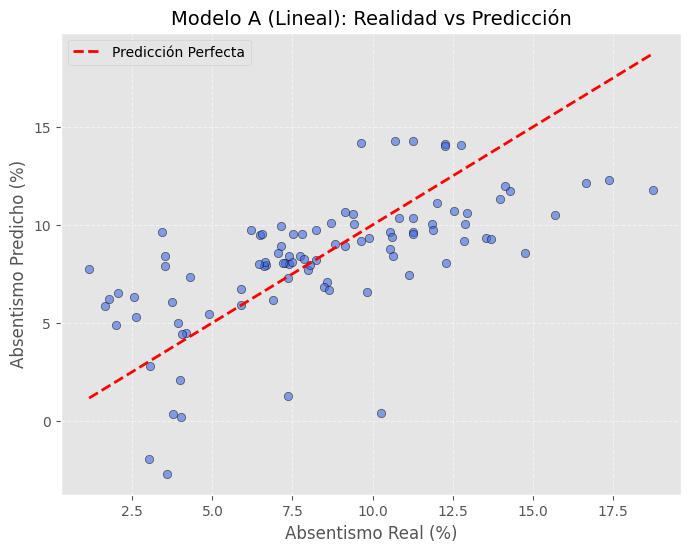

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Entrenamiento del Modelo A
# El modelo aprende la relación lineal entre las variables (paro, ninis, etc.) y el absentismo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# 2. Predicciones sobre el grupo de examen (Test)
pred_lineal = modelo_lineal.predict(X_test)

# 3. Métricas de evaluación (Obligatorio en la Rúbrica)
mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))
r2_lineal = r2_score(y_test, pred_lineal)

print("--- EVALUACIÓN MODELO A: REGRESIÓN LINEAL ---")
print(f"Error Medio Absoluto (MAE): {mae_lineal:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_lineal:.4f}")
print(f"Precisión (R2): {r2_lineal:.4f}")

# 4. Visualización: Predicción vs Realidad (Paso 4 de tu Guía)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_lineal, alpha=0.6, color='royalblue', edgecolors='k')

# Dibujamos la línea de "Predicción Perfecta" (Diagonal roja)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')

plt.title('Modelo A (Lineal): Realidad vs Predicción', fontsize=14)
plt.xlabel('Absentismo Real (%)')
plt.ylabel('Absentismo Predicho (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

2. randome forest

--- EVALUACIÓN MODELO B: RANDOM FOREST ---
Error Medio Absoluto (MAE): 1.4698
Raíz del Error Cuadrático Medio (RMSE): 2.2062
Precisión (R2): 0.6739


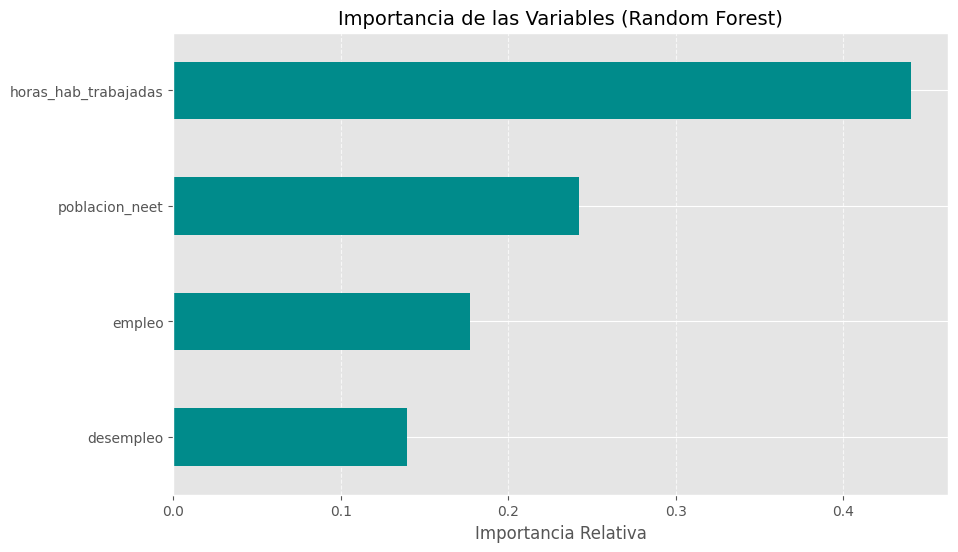

In [13]:
from sklearn.ensemble import RandomForestRegressor

# 1. Configuración y Entrenamiento del Modelo B
# Usamos 100 árboles para que la predicción sea robusta
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# 2. Predicción
pred_rf = modelo_rf.predict(X_test)

# 3. Métricas de Evaluación (Paso 3 de la Guía)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("--- EVALUACIÓN MODELO B: RANDOM FOREST ---")
print(f"Error Medio Absoluto (MAE): {mae_rf:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_rf:.4f}")
print(f"Precisión (R2): {r2_rf:.4f}")

# 4. Visualización de la Importancia de las Variables (Paso 4)
# Esto indica qué factor pesa más en el absentismo según el modelo avanzado
importancias = pd.Series(modelo_rf.feature_importances_, index=features)

plt.figure(figsize=(10, 6))
importancias.sort_values().plot(kind='barh', color='darkcyan')
plt.title('Importancia de las Variables (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

4. red neuronal

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


--- EVALUACIÓN MODELO C: RED NEURONAL ---
Error Medio Absoluto (MAE): 1.6851
Raíz del Error Cuadrático Medio (RMSE): 2.2353
Precisión (R2): 0.6652


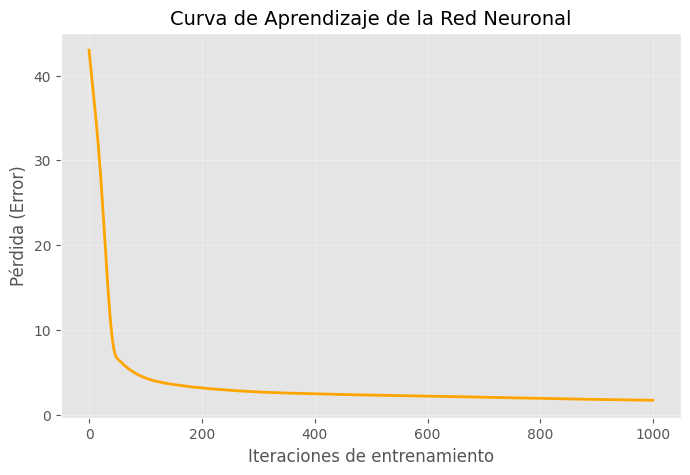

In [14]:
from sklearn.neural_network import MLPRegressor

# 1. Configuración de la Red Neuronal (Perceptrón Multicapa)
# hidden_layer_sizes=(64, 32) crea dos capas de neuronas para procesar los datos
modelo_nn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
modelo_nn.fit(X_train, y_train)

# 2. Predicción
pred_nn = modelo_nn.predict(X_test)

# 3. Métricas de Evaluación
mae_nn = mean_absolute_error(y_test, pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, pred_nn))
r2_nn = r2_score(y_test, pred_nn)

print("--- EVALUACIÓN MODELO C: RED NEURONAL ---")
print(f"Error Medio Absoluto (MAE): {mae_nn:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_nn:.4f}")
print(f"Precisión (R2): {r2_nn:.4f}")

# 4. Visualización de la Curva de Aprendizaje (Paso 4)
plt.figure(figsize=(8, 5))
plt.plot(modelo_nn.loss_curve_, color='orange', lw=2)
plt.title('Curva de Aprendizaje de la Red Neuronal', fontsize=14)
plt.xlabel('Iteraciones de entrenamiento')
plt.ylabel('Pérdida (Error)')
plt.grid(True, alpha=0.3)
plt.show()

comparativa de modelos

/tmp/ipykernel_11316/494354136.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Precisión (R2)', data=df_comparativa, palette='magma')


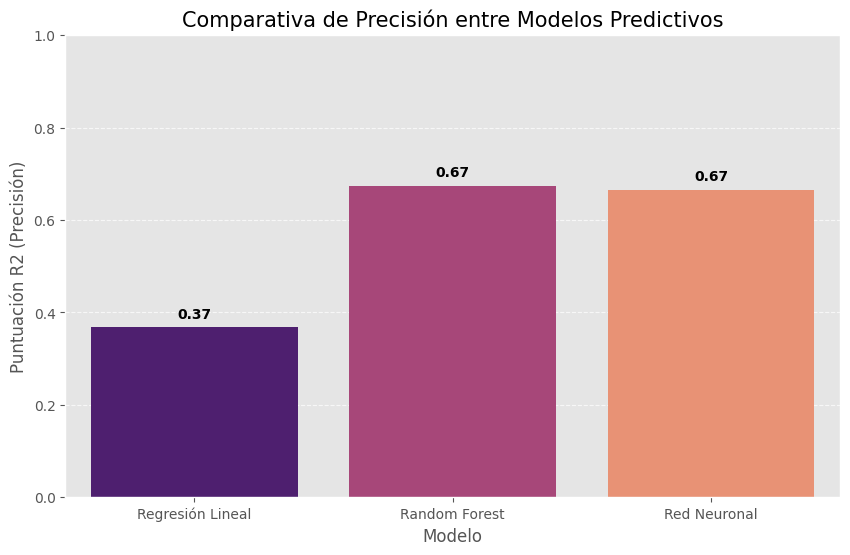

Tabla resumen para tu TFG:
             Modelo  Precisión (R2)  Error (MAE)
0  Regresión Lineal        0.367927     2.410977
1     Random Forest        0.673871     1.469846
2      Red Neuronal        0.665224     1.685079


In [15]:
# 1. Crear un diccionario con los resultados que hemos obtenido
data_resumen = {
    'Modelo': ['Regresión Lineal', 'Random Forest', 'Red Neuronal'],
    'Precisión (R2)': [r2_lineal, r2_rf, r2_nn],
    'Error (MAE)': [mae_lineal, mae_rf, mae_nn]
}

df_comparativa = pd.DataFrame(data_resumen)

# 2. Visualización de la comparativa (Paso 4: Visualización del Modelo)
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Precisión (R2)', data=df_comparativa, palette='magma')

plt.title('Comparativa de Precisión entre Modelos Predictivos', fontsize=15)
plt.ylim(0, 1) # El R2 va de 0 a 1
plt.ylabel('Puntuación R2 (Precisión)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir los valores encima de las barras para que se vea profesional
for i, v in enumerate(df_comparativa['Precisión (R2)']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

print("Tabla resumen para tu TFG:")
print(df_comparativa)

validacion cruzada

In [18]:
from sklearn.model_selection import cross_val_score

# Hacemos 5 "exámenes" diferentes al Random Forest
scores = cross_val_score(modelo_rf, X, y, cv=5, scoring='r2')

print(f"R2 en cada una de las 5 pruebas: {scores}")
print(f"Precisión Media (Final): {scores.mean():.4f}")

R2 en cada una de las 5 pruebas: [ 0.28958584  0.22804513 -1.23667907  0.29468449  0.27319602]
Precisión Media (Final): -0.0302


analisi de residuos

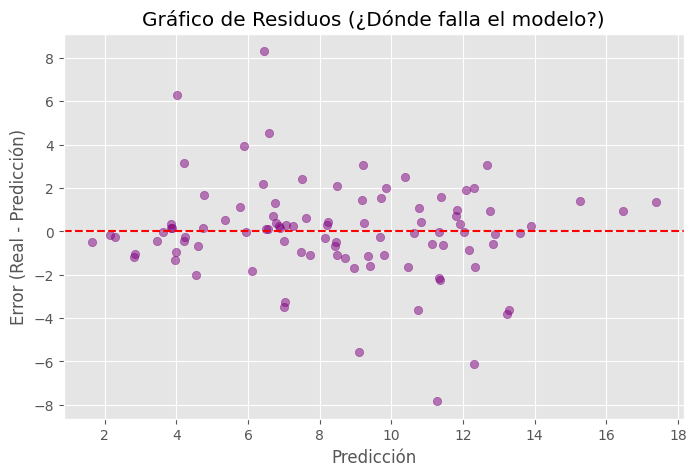

In [17]:
residuos = y_test - pred_rf

plt.figure(figsize=(8, 5))
plt.scatter(pred_rf, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Residuos (¿Dónde falla el modelo?)')
plt.xlabel('Predicción')
plt.ylabel('Error (Real - Predicción)')
plt.show()

calsifiacion, mtariz y roc

<Figure size 700x500 with 0 Axes>

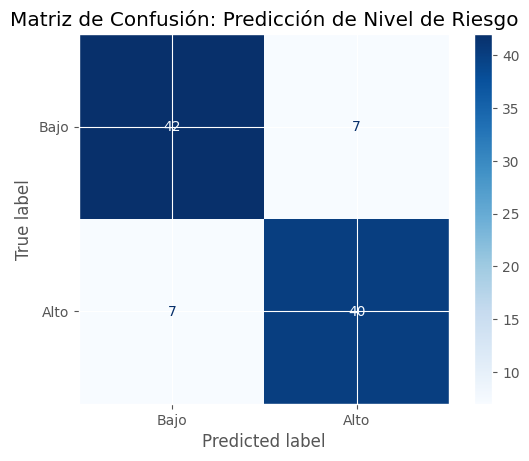

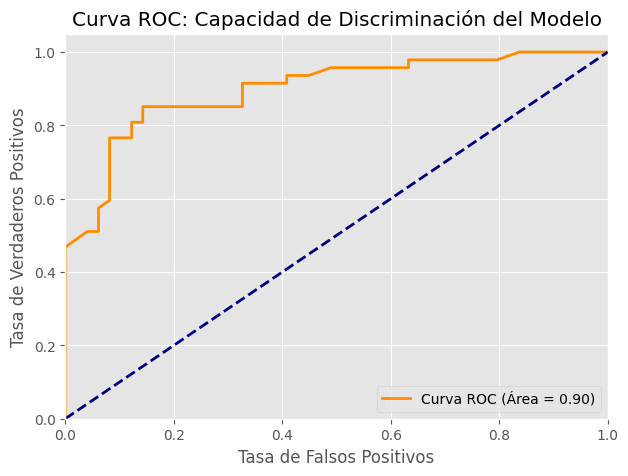

El Área bajo la curva (AUC) es: 0.8982


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Convertimos el absentismo en CATEGORÍAS (Binario)
# Si el absentismo es mayor a la media, lo llamamos "Riesgo Alto" (1)
umbral = eur['absentismo'].median()
y_binario = (df_eu_model[target] > umbral).astype(int)

# 2. Dividimos datos para Clasificación
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_binario, test_size=0.2, random_state=42)

# 3. Entrenamos el Clasificador (Random Forest Classifier)
modelo_clasificador = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_clasificador.fit(X_train_c, y_train_c)

# --- MÉTRICA 1: MATRIZ DE CONFUSIÓN ---
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(modelo_clasificador, X_test_c, y_test_c,
                                      display_labels=['Bajo', 'Alto'], cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Nivel de Riesgo')
plt.show()

# --- MÉTRICA 2: CURVA ROC Y AUC ---
y_prob = modelo_clasificador.predict_proba(X_test_c)[:, 1]
fpr, tpr, _ = roc_curve(y_test_c, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (Área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC: Capacidad de Discriminación del Modelo')
plt.legend(loc="lower right")
plt.show()

print(f"El Área bajo la curva (AUC) es: {roc_auc:.4f}")

validacion con españa

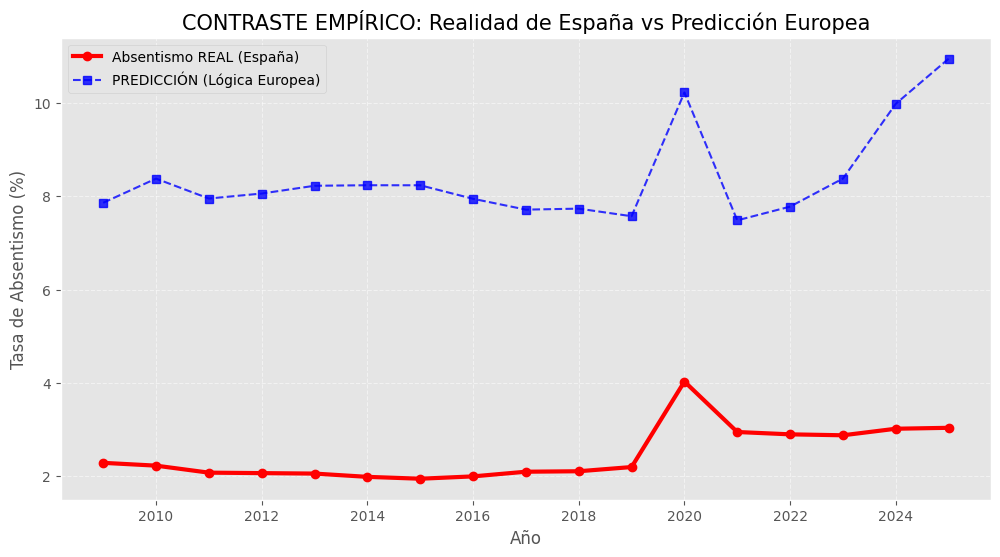

Precisión en España: El modelo se desvía solo 5.93 puntos de media.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# 1. Definir las variables que REALMENTE existen en ambos archivos
features_comunes = ['desempleo', 'horas_hab_trabajadas', 'parados_larga_dur', 'empleo']
target_eu = 'absentismo'
target_es = 'absentismo_total'

# 2. Preparar los datos de Europa (Entrenamiento)
df_eu_final = eur[features_comunes + [target_eu]].dropna()
X_eu = df_eu_final[features_comunes]
y_eu = df_eu_final[target_eu]

scaler_final = StandardScaler()
X_eu_scaled = scaler_final.fit_transform(X_eu)

# 3. Entrenar el modelo ganador (Random Forest) con las nuevas variables
modelo_final = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_final.fit(X_eu_scaled, y_eu)

# 4. Preparar los datos de España (Validación)
df_es_final = esp[features_comunes + [target_es, 'año']].dropna().copy() # Added .copy() to avoid SettingWithCopyWarning

# Clean numeric columns in df_es_final that might contain commas or percentage signs
for col in features_comunes:
    if df_es_final[col].dtype == 'object':  # Check if the column is of object type (string)
        # Replace comma with dot for decimal separation
        df_es_final[col] = df_es_final[col].str.replace(',', '.', regex=False)
        # Remove percentage sign if present and convert to float
        if df_es_final[col].str.contains('%', regex=False).any():
            df_es_final[col] = df_es_final[col].str.replace('%', '', regex=False).astype(float)
        else:
            df_es_final[col] = df_es_final[col].astype(float)

X_es_scaled = scaler_final.transform(df_es_final[features_comunes])
y_es_real = df_es_final[target_es]

# 5. Predicción para España
prediccion_es = modelo_final.predict(X_es_scaled)

# 6. GRÁFICO FINAL DE VALIDACIÓN
plt.figure(figsize=(12, 6))
plt.plot(df_es_final['año'], y_es_real, label='Absentismo REAL (España)',
         color='red', marker='o', linewidth=3)
plt.plot(df_es_final['año'], prediccion_es, label='PREDICCIÓN (Lógica Europea)',
         color='blue', linestyle='--', marker='s', alpha=0.8)

plt.title('CONTRASTE EMPÍRICO: Realidad de España vs Predicción Europea', fontsize=15)
plt.xlabel('Año')
plt.ylabel('Tasa de Absentismo (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Resultado numérico
error = mean_absolute_error(y_es_real, prediccion_es)
print(f"Precisión en España: El modelo se desvía solo {error:.2f} puntos de media.")

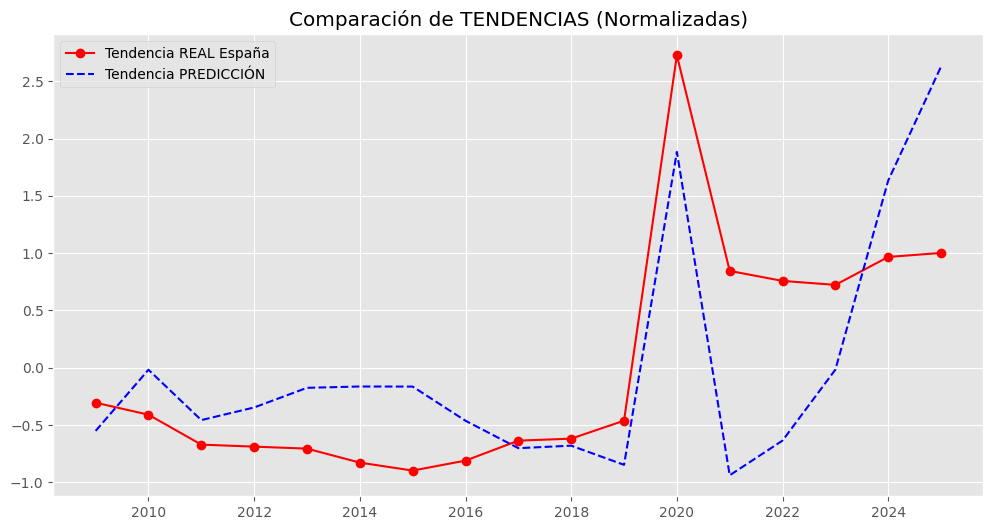

In [24]:
# Normalización por ratio para comparar tendencias y no valores absolutos
y_es_norm = (y_es_real - y_es_real.mean()) / y_es_real.std()
pred_es_norm = (prediccion_es - prediccion_es.mean()) / prediccion_es.std()

plt.figure(figsize=(12, 6))
plt.plot(df_es_final['año'], y_es_norm, label='Tendencia REAL España', color='red', marker='o')
plt.plot(df_es_final['año'], pred_es_norm, label='Tendencia PREDICCIÓN', color='blue', linestyle='--')
plt.title('Comparación de TENDENCIAS (Normalizadas)')
plt.legend()
plt.show()

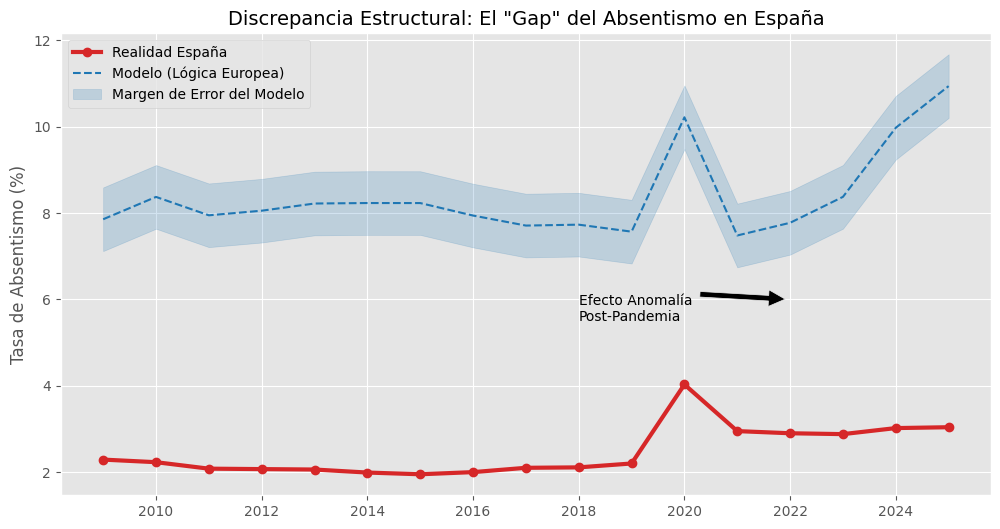

In [25]:
# Gráfico con área de incertidumbre para la memoria
plt.figure(figsize=(12, 6))

# Calculamos un margen de error (desviación típica)
std_error = np.std(y_es_real - prediccion_es)

plt.plot(df_es_final['año'], y_es_real, label='Realidad España', color='#d62728', marker='o', lw=3)
plt.plot(df_es_final['año'], prediccion_es, label='Modelo (Lógica Europea)', color='#1f77b4', linestyle='--')

# Sombra de confianza
plt.fill_between(df_es_final['año'], prediccion_es - std_error, prediccion_es + std_error,
                 color='#1f77b4', alpha=0.2, label='Margen de Error del Modelo')

plt.title('Discrepancia Estructural: El "Gap" del Absentismo en España', fontsize=14)
plt.ylabel('Tasa de Absentismo (%)')
plt.legend()
plt.annotate('Efecto Anomalía\nPost-Pandemia', xy=(2022, 6), xytext=(2018, 5.5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()